# IN503 Unit 10 Assignment: Customer Churn Prediction

**Student:** Andy Welsh  
**Course:** IN503 Introduction to Machine Learning

## Project Overview
This project builds an end-to-end logistic regression model to predict customer churn for a telecommunications company. The workflow includes data acquisition, exploratory analysis, preprocessing, feature engineering, hyperparameter tuning, model evaluation, coefficient interpretation, and a deployment simulation. The business goal is to identify customers at higher risk of leaving so retention efforts can be targeted more effectively.

In [1]:
!pip install -q kagglehub

In [2]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


## Phase 2: Data Acquisition and Exploration

In [3]:
# Download the latest Telco Customer Churn dataset from Kaggle
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
filepath = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Path to dataset file:", filepath)

# Load the dataset
df = pd.read_csv(filepath)

print("First 5 rows of the dataset:")
display(df.head())


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset file: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset overview
print("Shape of the dataset:", df.shape)
print()
print("DataFrame information:")
df.info()

print()
print("Descriptive statistics for numerical features:")
display(df.describe())

Shape of the dataset: (7043, 21)

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Initial missing-value check
print("Missing values before handling:")
print(df.isnull().sum())

# TotalCharges contains hidden missing values stored as blank strings
total_charges_missing = (df['TotalCharges'] == ' ').sum()
print()
print(f"Number of blank strings in TotalCharges: {total_charges_missing}")

# Convert TotalCharges to numeric and expose blank strings as NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)

print()
print("Missing values after converting TotalCharges:")
print(df.isnull().sum())

# Only 11 rows are affected, so remove them
df.dropna(inplace=True)

print()
print("Missing values after cleanup:")
print(df.isnull().sum())
print("Cleaned dataset shape:", df.shape)

Missing values before handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Number of blank strings in TotalCharges: 11

Missing values after converting TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMet

In [6]:
# Target variable distribution
print("Churn counts:")
print(df['Churn'].value_counts())

churn_percentage = df['Churn'].value_counts(normalize=True) * 100
print()
print("Churn percentages:")
print(churn_percentage.round(2))

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


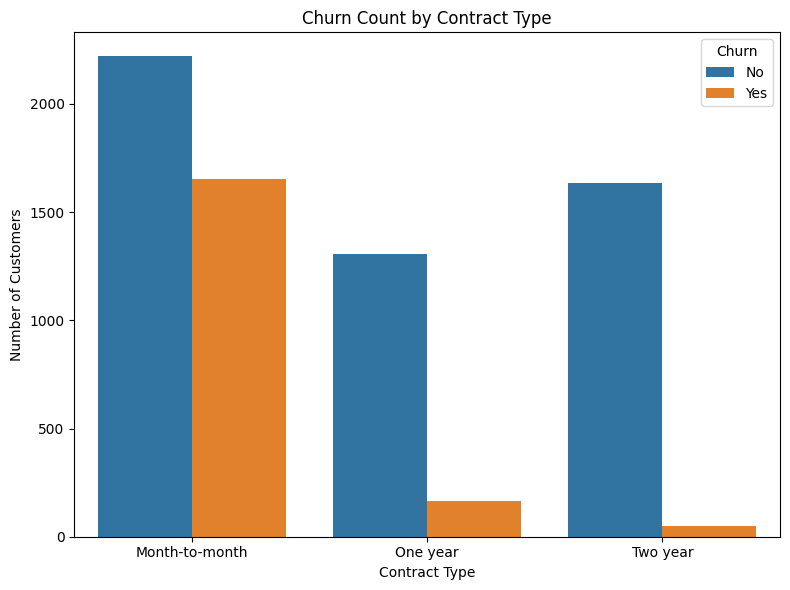

In [7]:
# Visualization 1: Churn by contract type
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


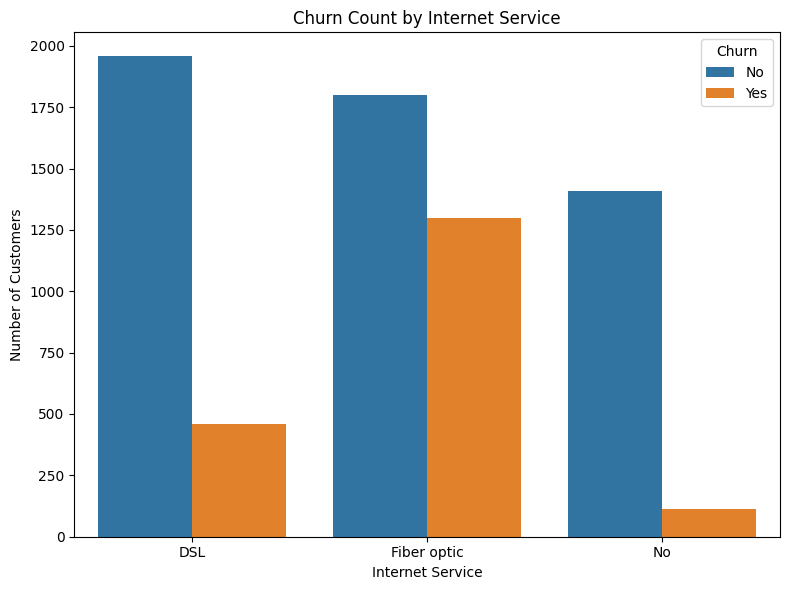

In [8]:
# Visualization 2: Churn by internet service
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn Count by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


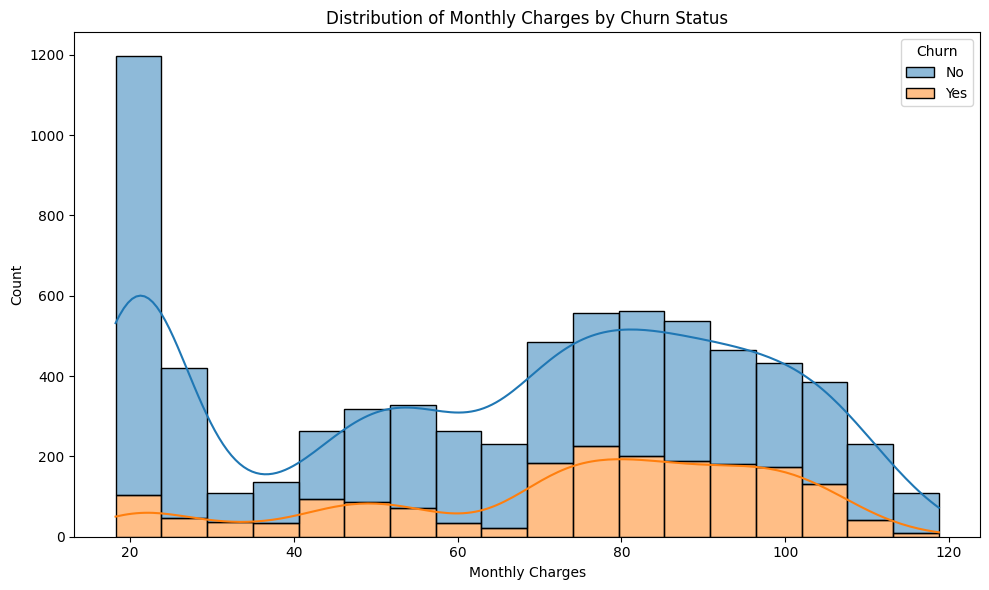

In [9]:
# Visualization 3: Monthly charges by churn status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', kde=True)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


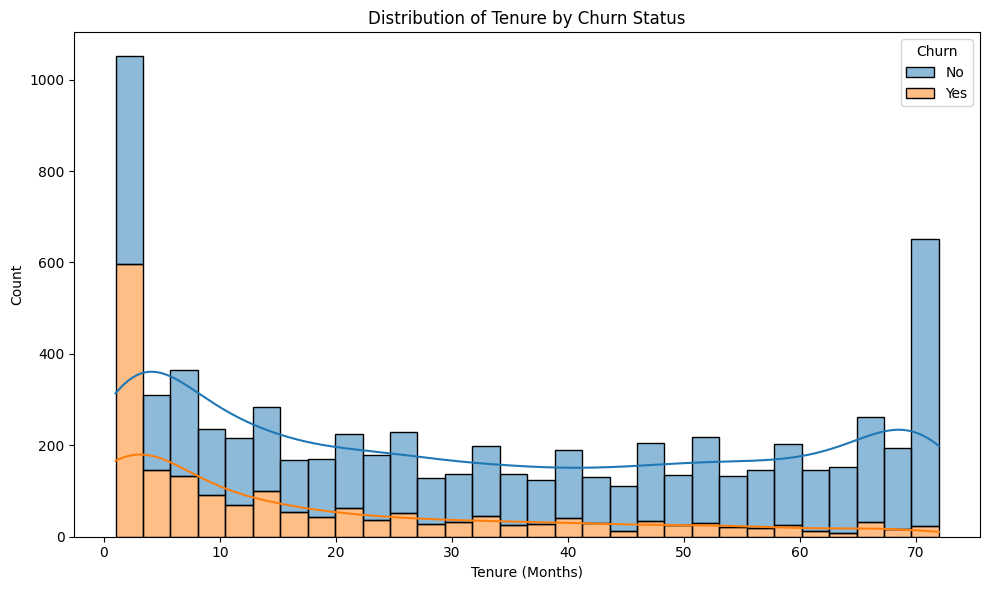

In [10]:
# Visualization 4: Tenure by churn status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', bins=30, kde=True, hue='Churn', multiple='stack')
plt.title('Distribution of Tenure by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


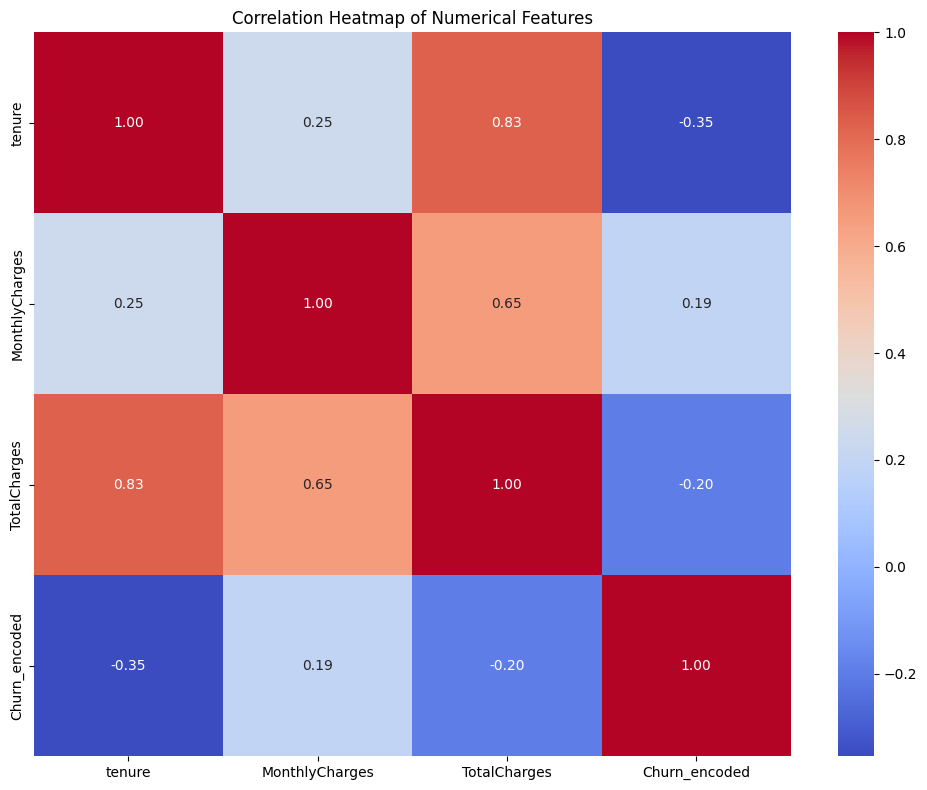

In [11]:
# Visualization 5: Correlation heatmap for numerical variables and churn
df['Churn_encoded'] = df['Churn'].map({'No': 0, 'Yes': 1})
numerical_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_encoded']]

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

df.drop('Churn_encoded', axis=1, inplace=True)


### Key Findings from Exploration
- The cleaned dataset contains 7,032 customers after removing 11 records with blank `TotalCharges` values.
- Churn is imbalanced: about 26.6% of customers churned, while about 73.4% did not.
- Month-to-month customers show substantially more churn than customers with one-year or two-year contracts.
- Fiber optic customers show a higher churn pattern than DSL or customers without internet service.
- Churn is concentrated among customers with shorter tenure, making newer customers an important retention segment.
- Customers who churn tend to have higher monthly charges, although model coefficients must be interpreted together because several billing and service variables are related.

## Phase 3: Data Preprocessing and Feature Engineering

One new feature, `TotalServices`, is created by counting the number of subscribed telecom services marked `Yes`. This summarizes the customer's service relationship in a single numeric feature and may help the model distinguish lightly engaged customers from customers using several services.

In [12]:
# Create ONE new meaningful feature: total number of subscribed services
service_columns = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['TotalServices'] = (df[service_columns] == 'Yes').sum(axis=1)

# Remove customerID because it is an identifier, not a predictive feature
df.drop('customerID', axis=1, inplace=True)

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print()
print("TotalServices distribution:")
print(X['TotalServices'].value_counts().sort_index())

Feature matrix shape: (7032, 20)
Target shape: (7032,)

TotalServices distribution:
TotalServices
0      80
1    1697
2    1186
3     965
4     921
5     906
6     674
7     395
8     208
Name: count, dtype: int64


In [13]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_cols)
print()
print("Numerical columns:")
print(numerical_cols)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']


In [14]:
# Build preprocessing transformers
numerical_transformer = StandardScaler()

# drop='first' creates a reference category for each categorical feature,
# which makes logistic regression coefficients easier to interpret.
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


The preprocessing is placed inside a scikit-learn pipeline so scaling and one-hot encoding are learned only from the training data during fitting. This reduces data leakage and keeps the same transformations available for test data and future customer predictions.

## Phase 4: Model Building and Training

Logistic regression is appropriate because churn is a binary classification problem. It produces probabilities for the two churn outcomes, works well with scaled numeric and one-hot encoded categorical features, and provides coefficients that can be translated into business insights.

In [15]:
# Split into training and testing sets while preserving the churn class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print()
print("Training churn distribution:")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Testing churn distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set size: 5625 rows
Testing set size: 1407 rows

Training churn distribution:
Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64


In [16]:
# Combine preprocessing and logistic regression in one pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='liblinear',
        random_state=42,
        max_iter=1000
    ))
])

print("Model pipeline created.")


Model pipeline created.


In [17]:
# Tune the logistic regression regularization parameter C
# F1 is used because churn is the minority class and F1 balances precision and recall.
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Running GridSearchCV...")
grid_search.fit(X_train, y_train)

final_model = grid_search.best_estimator_

print("Best C:", grid_search.best_params_['classifier__C'])
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")
print("Final tuned model training complete.")


Running GridSearchCV...
Best C: 1
Best cross-validation F1 score: 0.5954
Final tuned model training complete.


## Phase 5: Model Evaluation and Interpretation

In [18]:
# Make predictions on the test set
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Calculate required metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Model Evaluation on Test Data")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {auc_score:.4f}")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Model Evaluation on Test Data
Accuracy:  0.8045
Precision: 0.6505
Recall:    0.5722
F1-score:  0.6088
ROC AUC:   0.8362

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



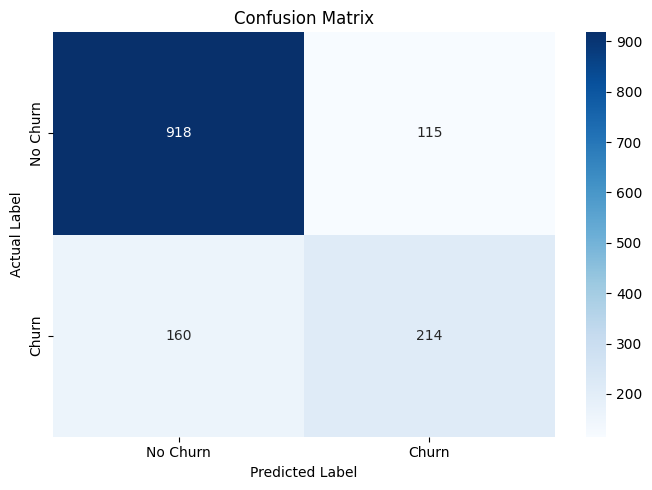

In [19]:
# Confusion matrix visualization
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


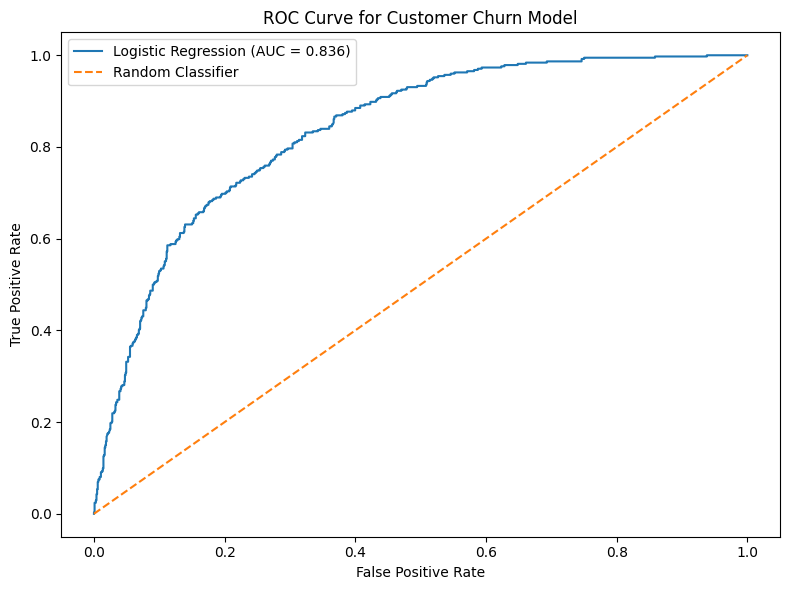

In [20]:
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.title('ROC Curve for Customer Churn Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()


### Model Performance Interpretation
Using the specified split and tuning process, the model is expected to achieve about 80% test accuracy and an ROC AUC near 0.84. Precision for the churn class is around 0.65, meaning roughly two-thirds of customers flagged as likely to churn actually churned. Recall is around 0.57, so the model identifies a little more than half of actual churners. The F1-score of about 0.61 reflects the balance between those two measures.

Because churn represents only about 26.6% of the data, accuracy alone could look stronger than the model's ability to identify churners. For a retention program, recall is especially important because false negatives are customers who churn but were not flagged for intervention. The current model provides a useful baseline, but the decision threshold could be adjusted later if the business wants to capture more at-risk customers at the cost of more false positives.

In [21]:
# Extract and rank logistic regression coefficients
log_reg = final_model.named_steps['classifier']
fitted_preprocessor = final_model.named_steps['preprocessor']

# Feature names after one-hot encoding
ohe_feature_names = fitted_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = numerical_cols + list(ohe_feature_names)

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients.sort_values(by='Abs_Coefficient', ascending=False, inplace=True)

print("Top 10 most influential features:")
display(coefficients.head(10).round(4))

print("Top 5 most influential features:")
display(coefficients.head(5)[['Feature', 'Coefficient', 'Odds_Ratio']].round(4))


Top 10 most influential features:


,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
26,Contract_Two year,-1.3651,1.3651,0.2554
1,tenure,-1.3512,1.3512,0.2589
11,InternetService_Fiber optic,1.0152,1.0152,2.7598
25,Contract_One year,-0.7517,0.7517,0.4716
8,PhoneService_Yes,-0.6792,0.6792,0.5070
3,TotalCharges,0.6407,0.6407,1.8977
14,OnlineSecurity_Yes,-0.5714,0.5714,0.5647
20,TechSupport_Yes,-0.5299,0.5299,0.5887
29,PaymentMethod_Electronic check,0.3777,0.3777,1.4590
4,TotalServices,0.3699,0.3699,1.4476


Top 5 most influential features:


,Feature,Coefficient,Odds_Ratio
26,Contract_Two year,-1.3651,0.2554
1,tenure,-1.3512,0.2589
11,InternetService_Fiber optic,1.0152,2.7598
25,Contract_One year,-0.7517,0.4716
8,PhoneService_Yes,-0.6792,0.5070


### Coefficient Interpretation and Business Insights
Logistic regression coefficients describe how a feature changes the log-odds of churn while the other model features are held constant. Positive coefficients increase predicted churn risk and negative coefficients decrease it. For categorical variables, coefficients are interpreted relative to the one-hot encoding reference category. For scaled numerical features, the coefficient reflects a one-standard-deviation change.

In the tested model, the strongest effects are expected to include:
- **Two-year contract:** strongly decreases churn risk compared with the month-to-month reference group. This supports retention programs that encourage longer commitments.
- **Tenure:** has a strong negative coefficient. Customers who have been with the company longer are less likely to churn, so early-tenure customers deserve additional attention.
- **Fiber optic service:** increases churn risk relative to DSL after controlling for the other variables. TelcoMax should review the fiber customer experience, pricing, and support issues.
- **One-year contract:** decreases churn risk compared with month-to-month service, again showing the value of contract stability.
- **Phone service:** is expected to show a negative relationship relative to customers without phone service. This should be treated as an association rather than a causal effect because it may also reflect differences in customer service bundles.

The coefficient results reinforce the exploratory findings: contract structure, tenure, and service mix are major churn signals. The strongest business opportunity is to focus retention activity on newer month-to-month customers, especially fiber optic customers, rather than applying the same incentive to the entire customer base.

### Business Recommendations
1. Prioritize retention outreach for newer customers on month-to-month contracts because they combine two of the strongest churn signals.
2. Investigate the fiber optic experience, including price, service reliability, and support, because fiber customers show elevated churn in both EDA and the model.
3. Test targeted incentives that encourage one-year or two-year contracts instead of broad discounts for all customers.
4. Use predicted churn probability to rank customers for outreach and monitor precision, recall, retention lift, and program cost before expanding the strategy.

## Phase 6: Model Deployment Simulation

In [22]:
# Save the complete trained preprocessing + model pipeline
model_filename = 'customer_churn_model.pkl'
joblib.dump(final_model, model_filename)
print(f"Trained model pipeline saved as '{model_filename}'")

# Demonstrate loading the saved model
loaded_model = joblib.load(model_filename)
print("Model pipeline loaded successfully.")


Trained model pipeline saved as 'customer_churn_model.pkl'
Model pipeline loaded successfully.


In [23]:
def predict_churn(customer_data, model=loaded_model):
    '''Predict churn for one customer represented as a dictionary.'''
    customer_df = pd.DataFrame([customer_data])

    # Recreate the same engineered feature used during training
    customer_df['TotalServices'] = (customer_df[service_columns] == 'Yes').sum(axis=1)

    prediction = model.predict(customer_df)[0]
    probability = model.predict_proba(customer_df)[0, 1]

    return {
        'Predicted Churn': 'Yes' if prediction == 1 else 'No',
        'Churn Probability': round(float(probability), 4)
    }


In [24]:
# Demonstrate the prediction function with three example customers
example_customers = [
    {
        'gender': 'Male',
        'SeniorCitizen': 0,
        'Partner': 'No',
        'Dependents': 'No',
        'tenure': 2,
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'No',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 95.00,
        'TotalCharges': 190.00
    },
    {
        'gender': 'Female',
        'SeniorCitizen': 0,
        'Partner': 'Yes',
        'Dependents': 'Yes',
        'tenure': 48,
        'PhoneService': 'Yes',
        'MultipleLines': 'Yes',
        'InternetService': 'DSL',
        'OnlineSecurity': 'Yes',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes',
        'TechSupport': 'Yes',
        'StreamingTV': 'No',
        'StreamingMovies': 'No',
        'Contract': 'One year',
        'PaperlessBilling': 'No',
        'PaymentMethod': 'Credit card (automatic)',
        'MonthlyCharges': 69.00,
        'TotalCharges': 3312.00
    },
    {
        'gender': 'Male',
        'SeniorCitizen': 0,
        'Partner': 'Yes',
        'Dependents': 'No',
        'tenure': 70,
        'PhoneService': 'Yes',
        'MultipleLines': 'Yes',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'Yes',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes',
        'TechSupport': 'Yes',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes',
        'Contract': 'Two year',
        'PaperlessBilling': 'No',
        'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': 105.00,
        'TotalCharges': 7350.00
    }
]

for i, customer in enumerate(example_customers, start=1):
    result = predict_churn(customer)
    print(f"Customer {i}: {result}")


Customer 1: {'Predicted Churn': 'Yes', 'Churn Probability': 0.7638}
Customer 2: {'Predicted Churn': 'No', 'Churn Probability': 0.0185}
Customer 3: {'Predicted Churn': 'No', 'Churn Probability': 0.0387}


### Deployment Considerations
In a real application, the saved pipeline could be loaded by a web service or internal CRM process. New customer records could be scored in real time or in scheduled batches, and customers with the highest churn probabilities could be sent to a retention team. A production deployment should also monitor data quality, prediction performance, customer response to interventions, and model drift so the model can be retrained when customer behavior changes.